In [1]:
import numpy as np
import pandas as pd

In [2]:
import os
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
image_path = r'C:\Users\KIIT\Documents\roco_dataset_extracted\all_data\train\radiology\images'

caption=r'C:\Users\KIIT\Documents\roco_dataset_extracted\all_data\train\radiology\captions.txt'


In [5]:
df =pd.read_table(caption, header=None, names=['image_name', 'caption'])


print(df.head())


   image_name                                            caption
0  ROCO_00002   Computed tomography scan in axial view showin...
1  ROCO_00003   Bacterial contamination occurred after comple...
2  ROCO_00004   The patient had residual paralysis of the han...
3  ROCO_00005      Panoramic radiograph after immediate loading.
4  ROCO_00007   Plain abdomen x-ray: Multiple air levels at t...


In [6]:
df.describe()

,image_name,caption
count,65450,65450
unique,65450,64772
top,ROCO_00002,Initial panoramic radiograph.
freq,1,19


In [7]:
df['caption_length']=df['caption'].str.len()

In [8]:
df.head()

,image_name,caption,caption_length
0,ROCO_00002,Computed tomography scan in axial view showin...,88
1,ROCO_00003,Bacterial contamination occurred after comple...,142
2,ROCO_00004,The patient had residual paralysis of the han...,320
3,ROCO_00005,Panoramic radiograph after immediate loading.,46
4,ROCO_00007,Plain abdomen x-ray: Multiple air levels at t...,124


In [9]:
print(df['caption_length'].describe())

count    65450.000000
mean       138.963453
std        104.237943
min          3.000000
25%         73.000000
50%        114.000000
75%        175.000000
max       2855.000000
Name: caption_length, dtype: float64


In [10]:
dlink_url = r'C:\Users\KIIT\Documents\roco_dataset_extracted\all_data\train\radiology\dlinks.txt'
dlink = pd.read_table(dlink_url, header=None, names=['image_id', 'dlink', 'image'])
print(dlink)

         image_id                                              dlink  \
0      ROCO_00002  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
1      ROCO_00003  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
2      ROCO_00004  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
3      ROCO_00005  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
4      ROCO_00007  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
...           ...                                                ...   
65445  ROCO_81819  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
65446  ROCO_81820  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
65447  ROCO_81821  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
65448  ROCO_81822  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
65449  ROCO_81823  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   

                                    image  
0                     AMHSR-4-14-g002.jpg  
1                  IJD2009-150251.001.jpg  
2  

In [11]:
dlink.describe()

,image_id,dlink,image
count,65450,65450,65450
unique,65450,37396,60990
top,ROCO_00002,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,gr1.jpg
freq,1,37,1444


In [12]:
# Define paths for each split (train, test, validation) and categories (radiology, non-radiology)
base_dir = r'C:\Users\KIIT\Documents\roco_dataset_extracted\all_data'

# Define the splits and categories
splits = ['train', 'test', 'validation']
categories = ['radiology', 'non-radiology']

# Initialize an empty list to store the data
data = []

# Loop through each split and category to read captions
for split in splits:
    for category in categories:
        # Define paths for images and captions.txt
        category_dir = os.path.join(base_dir, split, category)
        captions_file = os.path.join(category_dir, 'captions.txt')
        
        # Read the captions file if it exists
        if os.path.exists(captions_file):
            with open(captions_file, 'r', encoding='utf-8', errors='ignore') as file:
                # Read each line in the captions file
                for line in file:
                    image_id = line[:12]    # Assuming the first 12 characters are the image ID
                    caption = line[12:].strip()  # The rest of the line is the caption text
                    label = category  # Set label as 'radiology' or 'non-radiology'
                    
                    # Append to data list with image ID, caption, label, and split type
                    data.append([image_id, caption, label, split])

# Create a DataFrame with the collected data
df = pd.DataFrame(data, columns=['image_id', 'caption', 'Label', 'split'])

# Display the first few rows of the DataFrame to verify
df


,image_id,caption,Label,split
0,ROCO_00002\t,Computed tomography scan in axial view showing...,radiology,train
1,ROCO_00003\t,Bacterial contamination occurred after complet...,radiology,train
2,ROCO_00004\t,The patient had residual paralysis of the hand...,radiology,train
3,ROCO_00005\t,Panoramic radiograph after immediate loading.,radiology,train
4,ROCO_00007\t,Plain abdomen x-ray: Multiple air levels at th...,radiology,train
...,...,...,...,...
79743,ROCO_87894\t,Scanning electron photomicrograph of blood cel...,non-radiology,validation
79744,ROCO_87904\t,SEM of Solenopsis elhawagryi sp. n. minor work...,non-radiology,validation
79745,ROCO_87918\t,Under visualization through the anterolateral ...,non-radiology,validation
79746,ROCO_87936\t,The endoscopic view demonstrated progressive d...,non-radiology,validation


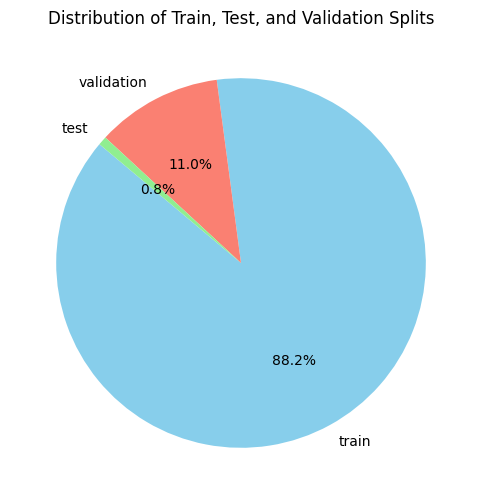

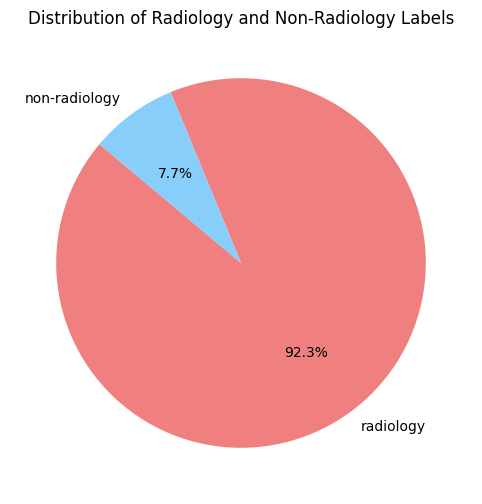

In [13]:
import matplotlib.pyplot as plt

# Pie chart for train/test/validation distribution
split_counts = df['split'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(split_counts, labels=split_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'salmon', 'lightgreen'])
plt.title("Distribution of Train, Test, and Validation Splits")
plt.show()

# Pie chart for radiology and non-radiology distribution
label_counts = df['Label'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'lightskyblue'])
plt.title("Distribution of Radiology and Non-Radiology Labels")
plt.show()


## ANALYSIS OF DATA

In [14]:
df['caption_length'] = df['caption'].str.len()

<Axes: xlabel='caption_length', ylabel='Count'>

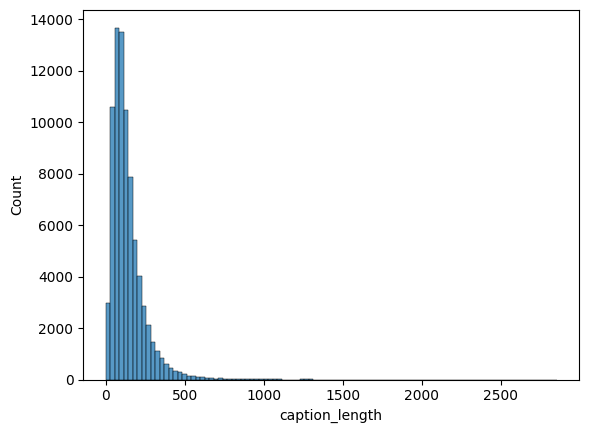

In [15]:
sns.histplot(df['caption_length'],bins=100)

In [16]:
from wordcloud import WordCloud

In [17]:
all_captions = ' '.join(df['caption'])

In [18]:
wordcloud = WordCloud(width=800, height=400, max_words=20).generate(all_captions)

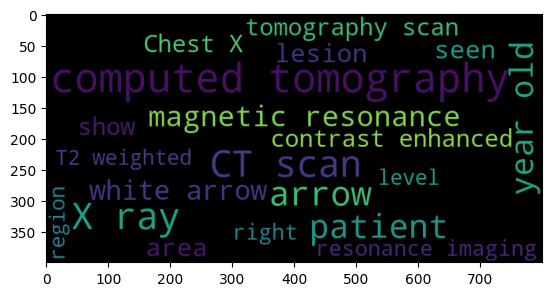

In [19]:
plt.imshow(wordcloud)

In [20]:
from collections import Counter
import re

In [21]:
words = re.findall(r'\w+', all_captions.lower())
# frequency of each word
word_counts = Counter(words)
# Display the most common words
print(word_counts.most_common(5))

[('the', 120433), ('of', 77601), ('and', 36235), ('a', 33406), ('in', 31768)]


In [22]:
top_words=word_counts.most_common(10)

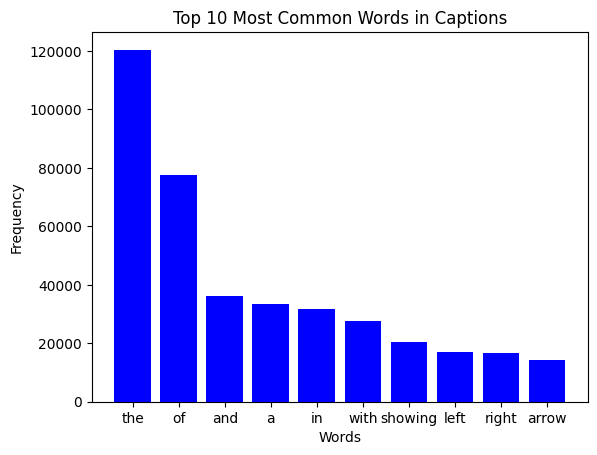

In [23]:
words, counts = zip(*top_words)
plt.bar(words, counts, color='blue')
plt.title("Top 10 Most Common Words in Captions")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

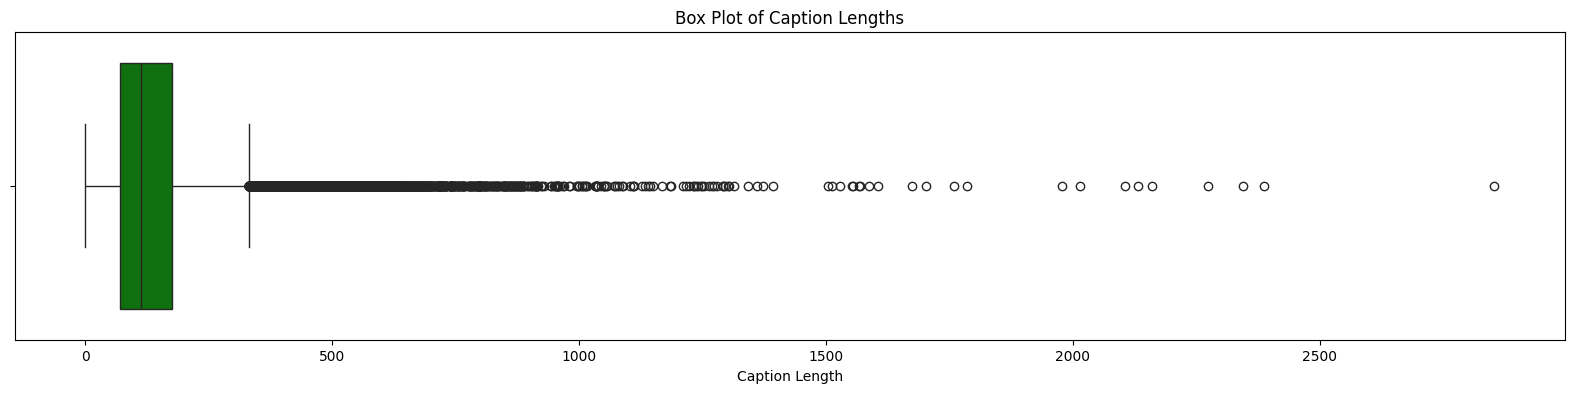

In [24]:
plt.figure(figsize=(20, 4))
sns.boxplot(x=df['caption_length'], color='green')
plt.title('Box Plot of Caption Lengths')
plt.xlabel('Caption Length')
plt.show()


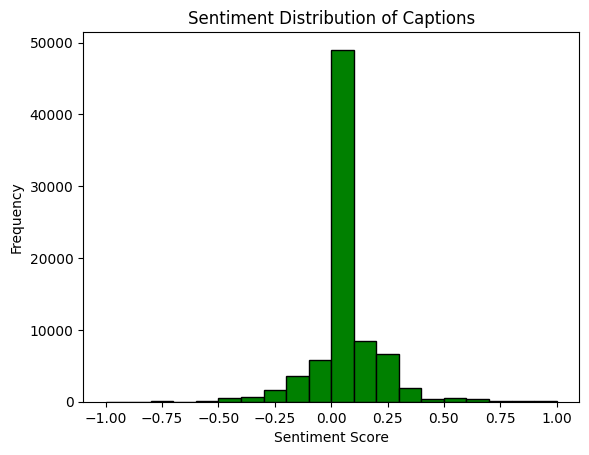

In [25]:
from textblob import TextBlob
sentiment_scores = df['caption'].apply(lambda x: TextBlob(x).sentiment.polarity)
plt.hist(sentiment_scores, bins=20, color='green', edgecolor='black')
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Sentiment Distribution of Captions")
plt.show()

### IMAGE PREPROCESSING

In [26]:
import cv2

In [27]:
image_files=[f for f in os.listdir(image_path) if f.endswith(".jpg")]

In [28]:
img_path=os.path.join(image_path,image_files[27])

In [29]:
img_path

'C:\\Users\\KIIT\\Documents\\roco_dataset_extracted\\all_data\\train\\radiology\\images\\PMC1097744_1476-7120-3-11-1.jpg'

In [30]:
img=cv2.imread(img_path)
img

array([[[102, 106,  40],
        [ 84,  88,  22],
        [ 95,  99,  33],
        ...,
        [100, 100,  36],
        [ 89,  91,  32],
        [ 85, 104,  17]],

       [[ 86,  90,  24],
        [ 61,  65,   0],
        [ 65,  69,   3],
        ...,
        [ 59,  68,   5],
        [ 62,  64,  12],
        [ 45,  34,   0]],

       [[ 95,  99,  33],
        [ 63,  67,   1],
        [ 64,  68,   2],
        ...,
        [ 98, 111,  79],
        [ 64,  74,  14],
        [ 52,  36,   0]],

       ...,

       [[ 93,  97,  31],
        [ 61,  65,   0],
        [ 63,  67,   1],
        ...,
        [ 62,  67,   0],
        [ 59,  65,   0],
        [ 40,  35,   4]],

       [[ 93,  97,  31],
        [ 61,  65,   0],
        [ 63,  67,   1],
        ...,
        [ 62,  67,   0],
        [ 59,  65,   0],
        [ 40,  35,   4]],

       [[ 44,  38,   1],
        [ 43,  37,   0],
        [ 41,  35,   0],
        ...,
        [ 43,  36,   3],
        [ 42,  35,   2],
        [ 39,  34,   1]]

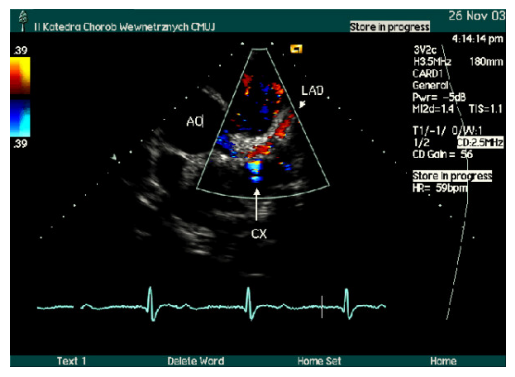

In [31]:
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off') 
plt.show()

In [32]:
image_rgb.shape

(433, 600, 3)

In [33]:
target_size=(224,224)
resizedimg=cv2.resize(image_rgb,target_size)

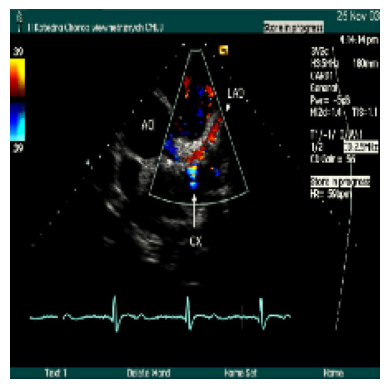

In [34]:
plt.imshow(resizedimg)
plt.axis('off')
plt.show()

In [35]:
img_processed=image_rgb

In [36]:
img_normalized=img_processed/255

In [37]:
import tensorflow as tf

In [38]:
img=np.expand_dims(img,axis=0)

In [39]:
datagen=tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=0.2
                                        )
it=datagen.flow(img,batch_size=1)
augmented_images=[next(it)[0] for _ in range(5)]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


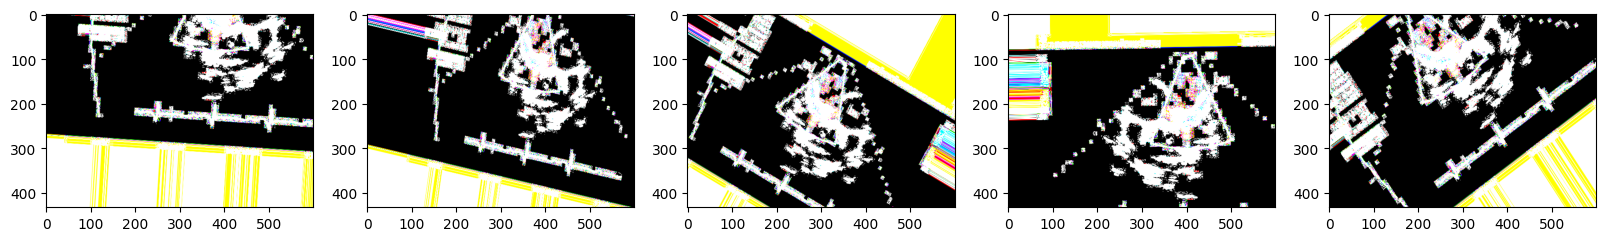

In [40]:

plt.figure(figsize=(20,5))
for i,aug_img in enumerate(augmented_images):
  plt.subplot(1,5,i+1)
  plt.imshow(aug_img)

### VGG16 FEATURE MAP EXTRACTION

In [41]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

In [42]:
  base_model=VGG16(weights="imagenet")

In [43]:
from tensorflow.keras.preprocessing import image

In [44]:
model=Model(inputs=base_model.input,outputs=base_model.get_layer("block5_conv3").output) 

In [45]:
def load_and_preprocess_image(img_path,target_size=(224,224)):
  img=image.load_img(img_path,target_size=target_size)
  img_array=image.img_to_array(img)
  img_array=np.expand_dims(img_array,axis=0)
  img_array=preprocess_input(img_array)
  return img_array

In [46]:
img=image.load_img(r"C:/Users/KIIT/Documents/roco_dataset_extracted/all_data/train/radiology/images/PMC1459185_1748-717X-1-7-8.jpg",target_size=(224,224))
img_array=image.img_to_array(img)

In [47]:
img_array.shape

(224, 224, 3)

In [48]:
img_array=np.expand_dims(img_array,axis=0)
img_array.shape

(1, 224, 224, 3)

In [49]:
feature_map=model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step


In [50]:
n_features=feature_map.shape[-1]

In [51]:
n_features

512

In [52]:
size=feature_map.shape[1]

In [53]:
from PIL import Image

In [54]:
img=Image.open(img_path)

In [55]:
img.size

(600, 433)

In [56]:
display_grid=np.zeros((size,size*n_features))

In [57]:
display_grid

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [58]:
for i in range(n_features):
  x=feature_map[0,:,:,i]
  x-=x.mean()
  x/=(x.std()+1e-5)
  x*=64
  x+=128
  x=np.clip(x,0,255).astype(int)
  display_grid[:,i*size:(i+1)*size]=x

In [59]:
scale=20./n_features

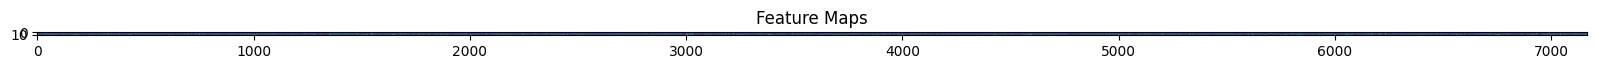

In [60]:
plt.figure(figsize=(scale*n_features,scale))
plt.title("Feature Maps")
plt.grid(False)
plt.imshow(display_grid,aspect="auto")

### Final Image captioning

In [64]:
train_images_path = "C:/Users/KIIT/Documents/roco_dataset_extracted/all_data/train/radiology/images"
train_captions_path = "C:/Users/KIIT/Documents/roco_dataset_extracted/all_data/train/radiology/traindata.csv"
val_images_path = "C:/Users/KIIT/Documents/roco_dataset_extracted/all_data/validation/radiology/images"
val_captions_path = "C:/Users/KIIT/Documents/roco_dataset_extracted/all_data/validation/radiology/valdata.csv"


In [65]:
def load_captions(captions_path):
    df = pd.read_csv(captions_path)
    return df
     

In [66]:
from keras.applications import VGG19
from keras.applications.vgg19 import preprocess_input
from keras.preprocessing.image import load_img, img_to_array
from keras.models import Model


In [71]:
def preprocess_images(images_path, subset_size=1000):  # Changed max_images to subset_size
    vgg19 = VGG19(weights="imagenet")
    feature_extractor = Model(inputs=vgg19.input, outputs=vgg19.get_layer("fc2").output)

    features = {}
    all_images = [img_name for img_name in os.listdir(images_path) if img_name.lower().endswith(('png', 'jpg', 'jpeg'))]

    if len(all_images) > subset_size:
        all_images = random.sample(all_images, subset_size)

    for img_name in all_images:
        img_path = os.path.join(images_path, img_name)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)

        feature = feature_extractor.predict(img_array)
        features[img_name] = feature.flatten()
    
    return features


In [73]:
subset_size = 10
train_features = preprocess_images(train_images_path, subset_size=subset_size)
val_features = preprocess_images(val_images_path, subset_size=subset_size)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step


In [74]:
train_captions = load_captions(train_captions_path)
val_captions = load_captions(val_captions_path)

In [75]:
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from sklearn.model_selection import train_test_split
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_captions['caption'])

In [76]:

vocab_size = len(tokenizer.word_index) + 1
max_len = max([len(c.split()) for c in train_captions['caption']])

In [77]:


def create_sequences(features, captions, tokenizer, max_len):
    X1, X2, y = [], [], []
    missing_keys = []
    valid_keys = set(features.keys())

    for label, caption in zip(captions['name'], captions['caption']):
        if label in valid_keys:
            seq = tokenizer.texts_to_sequences([caption])[0]
            if len(seq) < 2:
                print(f"Skipping caption '{caption}' for label '{label}' as it is too short.")
                continue

            for i in range(1, len(seq)):
                in_seq, out_seq = seq[:i], seq[i]
                in_seq = pad_sequences([in_seq], maxlen=max_len)[0]
                out_seq_one_hot = np.zeros(vocab_size)
                out_seq_one_hot[out_seq] = 1

                feature = features[label].flatten() if len(features[label].shape) > 1 else features[label]
                X1.append(feature)
                X2.append(in_seq)
                y.append(out_seq_one_hot)
        else:
            missing_keys.append(label)

    if missing_keys:
        print(f"Number of missing keys: {len(missing_keys)}")
        print(f"Missing keys: {missing_keys[:10]}{'...' if len(missing_keys) > 10 else ''}")  # Print first 10 missing keys

    return np.array(X1), np.array(X2), np.array(y)

     

In [78]:

X1_train, X2_train, y_train = create_sequences(train_features, train_captions, tokenizer, max_len)
print(f"X1_train shape: {X1_train.shape}")
print(f"X2_train shape: {X2_train.shape}")
print(f"y_train shape: {y_train.shape}")

Number of missing keys: 65440
Missing keys: ['PMC4083729_AMHSR-4-14-g002.jpg', 'PMC2837471_IJD2009-150251.001.jpg', 'PMC2505281_11999_2007_30_Fig6_HTML.jpg', 'PMC3745845_IJD2013-683423.005.jpg', 'PMC4917066_amjcaserep-17-301-g001.jpg', 'PMC4805615_13244_2016_481_Fig12_HTML.jpg', 'PMC2584650_1757-1626-1-193-1.jpg', 'PMC3283944_JISP-15-414-g006.jpg', 'PMC4946383_HI-10-1-25-g003.jpg', 'PMC5646151_TOORTHJ-11-882_F2.jpg']...
X1_train shape: (226, 4096)
X2_train shape: (226, 410)
y_train shape: (226, 37660)


In [79]:
print(f"Number of valid samples: {len(X1_train)}")

Number of valid samples: 226


In [80]:
X1_train, X2_train, y_train = create_sequences(train_features, train_captions, tokenizer, max_len)
X1_val, X2_val, y_val = create_sequences(val_features, val_captions, tokenizer, max_len)

Number of missing keys: 65440
Missing keys: ['PMC4083729_AMHSR-4-14-g002.jpg', 'PMC2837471_IJD2009-150251.001.jpg', 'PMC2505281_11999_2007_30_Fig6_HTML.jpg', 'PMC3745845_IJD2013-683423.005.jpg', 'PMC4917066_amjcaserep-17-301-g001.jpg', 'PMC4805615_13244_2016_481_Fig12_HTML.jpg', 'PMC2584650_1757-1626-1-193-1.jpg', 'PMC3283944_JISP-15-414-g006.jpg', 'PMC4946383_HI-10-1-25-g003.jpg', 'PMC5646151_TOORTHJ-11-882_F2.jpg']...
Number of missing keys: 8170
Missing keys: ['PMC3970251_CRIONM2014-931546.003.jpg', 'PMC2766744_cios-1-176-g005.jpg', 'PMC3789931_poljradiol-78-3-35-g001.jpg', 'PMC2676075_p147_fig4a.jpg', 'PMC5292123_CRIGM2017-1710501.002.jpg', 'PMC4756892_CMJ-128-2946-g004.jpg', 'PMC2494540_1757-1626-1-52-1.jpg', 'PMC3339065_NAJMS-2-392-g001.jpg', 'PMC2636159_IndianJOphthalmol-56-269-g003.jpg', 'PMC5625558_1657-9534-cm-48-02-00088-gf1.jpg']...


In [81]:
from keras.layers import Input, LSTM, Embedding, Dense, Dropout, RNN, SimpleRNN
from keras.models import Model
def build_lstm_model(vocab_size, max_len):
    inputs1 = Input(shape=(4096,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    inputs2 = Input(shape=(max_len,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = LSTM(256)(se1)

    decoder1 = Dense(256, activation='relu')((fe2))
    outputs = Dense(vocab_size, activation='softmax')(decoder1)
    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    return model
     

In [82]:
def build_rnn_model(vocab_size, max_len):
    inputs1 = Input(shape=(4096,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    inputs2 = Input(shape=(max_len,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = SimpleRNN(256)(se1)

    decoder1 = Dense(256, activation='relu')((fe2))
    outputs = Dense(vocab_size, activation='softmax')(decoder1)
    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    return model
     

In [87]:
lstm_model = build_lstm_model(vocab_size, max_len)
lstm_model.fit([X1_train, X2_train], y_train, epochs=20, batch_size=64, validation_data=([X1_val, X2_val], y_val))

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 281ms/step - loss: 10.4461 - val_loss: 9.6683
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - loss: 7.4347 - val_loss: 9.9570
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - loss: 5.1164 - val_loss: 11.2266
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - loss: 4.3496 - val_loss: 11.5155
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - loss: 3.9282 - val_loss: 11.1193
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - loss: 3.7197 - val_loss: 10.4888
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - loss: 3.5599 - val_loss: 9.9255
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - loss: 3.4690 - val_loss: 9.5062
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - loss: 3.4672 - val_loss: 9.2019
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - loss: 3.4445 - val_loss: 8.9874
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - loss: 3.4524 - val_loss: 8.8739
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - loss: 3.3848 - v

In [88]:

rnn_model = build_rnn_model(vocab_size, max_len)
rnn_model.fit([X1_train, X2_train], y_train, epochs=20, batch_size=64, validation_data=([X1_val, X2_val], y_val))

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 274ms/step - loss: 10.4482 - val_loss: 9.6526
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - loss: 7.4963 - val_loss: 10.2356
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - loss: 5.2885 - val_loss: 11.2173
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 4.4272 - val_loss: 11.1483
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - loss: 4.1088 - val_loss: 10.6468
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - loss: 3.7344 - val_loss: 10.2020
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step - loss: 3.5644 - val_loss: 9.8356
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - loss: 3.4443 - val_loss: 9.5673
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - loss: 3.4371 - val_loss: 9.2947
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 3.4713 - val_loss: 9.0920
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - loss: 3.4417 - val_loss: 8.9491
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - loss: 3.3449 - 

In [89]:
lstm_loss = lstm_model.evaluate([X1_val, X2_val], y_val)
rnn_loss = rnn_model.evaluate([X1_val, X2_val], y_val)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9.0457
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.1033


In [90]:
print(f"LSTM Loss: {lstm_loss}")
print(f"RNN Loss: {rnn_loss}")

LSTM Loss: 8.835773468017578
RNN Loss: 8.870076179504395


In [91]:
import numpy as np
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_classes=2, random_state=42)

from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
	"max_depth": [3, None],
	"max_features": randint(1, 9),
	"min_samples_leaf": randint(1, 9),
	"criterion": ["gini", "entropy"]
}

tree = DecisionTreeClassifier()
tree_cv = RandomizedSearchCV(tree, param_dist, cv=5)
tree_cv.fit(X, y)

print("Tuned Decision Tree Parameters: {}".format(tree_cv.best_params_))
print("Best score is {}".format(tree_cv.best_score_))
     

Tuned Decision Tree Parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': 5, 'min_samples_leaf': 7}
Best score is 0.8109999999999999


In [92]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.datasets import make_classification


X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_classes=2, random_state=42)

c_space = np.logspace(-5, 8, 15)
param_grid = {'C': c_space}

logreg = LogisticRegression()
logreg_cv = GridSearchCV(logreg, param_grid, cv=5)

logreg_cv.fit(X, y)

print("Tuned Logistic Regression Parameters: {}".format(logreg_cv.best_params_))
print("Best score is {}".format(logreg_cv.best_score_))
     

Tuned Logistic Regression Parameters: {'C': 0.006105402296585327}
Best score is 0.853


In [93]:

!pip install hyperopt

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 14.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 31.1 MB/s eta 0:00:00


In [94]:
from hyperopt import fmin, tpe, hp, anneal, Trials, STATUS_OK

In [95]:
def objective(params):
    C = params['C']
    logreg = LogisticRegression(C=C)
    logreg.fit(X, y)
    accuracy = logreg.score(X, y)
    return {'loss': -accuracy, 'status': STATUS_OK}

space = {
    'C': hp.loguniform('C', -5, 8)
}

trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials
)

print("Best hyperparameters:", best)
best_trial = trials.best_trial

print("Best loss:", best_trial['result']['loss'])
print("Best C:", best_trial['misc']['vals']['C'][0])

100%|█████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 39.84trial/s, best loss: -0.86]
Best hyperparameters: {'C': 0.008369685111470154}
Best loss: -0.86
Best C: 0.008369685111470154


In [97]:
y_pred = lstm_model.predict([X1_val, X2_val])
y_pred_classes = np.argmax(y_pred, axis=-1)
y_val_classes = np.argmax(y_val, axis=-1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [98]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [100]:
accuracy = accuracy_score(y_val_classes, y_pred_classes)
precision = precision_score(y_val_classes, y_pred_classes, average='weighted')
recall = recall_score(y_val_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_val_classes, y_pred_classes, average='weighted')


C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [101]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-Score: ", f1)

Accuracy:  0.01744186046511628
Precision:  0.013565891472868215
Recall:  0.01744186046511628
F1-Score:  0.014396456256921373


In [102]:
from sklearn.metrics import classification_report
unique_classes = np.unique(y_val_classes)
target_names = [str(cls) for cls in unique_classes]
report = classification_report(y_val_classes, y_pred_classes, target_names=target_names, labels=unique_classes)
print("Classification Report: ")
print(report)
     

Classification Report: 
              precision    recall  f1-score   support

           1       0.06      0.12      0.08        17
           2       0.11      0.08      0.10        12
           3       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         6
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         3
          13       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         1
          17       0.00      0.00      0.00         1
          20       0.00      0.00      0.00         1
          24       0.00      0.00      0.00         1
          27       0.00      0.00      0.00         1
          28       0.00      0.00      0.00         2
          36       0.00      0.00      0.00         1
   

C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [105]:
pip install evaluate


   ---------------------------------------- 0.0/25.1 MB ? eta -:--:--
    --------------------------------------- 0.5/25.1 MB 3.4 MB/s eta 0:00:08
   -- ------------------------------------- 1.3/25.1 MB 3.9 MB/s eta 0:00:07
   ---- ----------------------------------- 2.9/25.1 MB 5.4 MB/s eta 0:00:05
   ------- -------------------------------- 5.0/25.1 MB 6.9 MB/s eta 0:00:03
   ------------- -------------------------- 8.7/25.1 MB 9.1 MB/s eta 0:00:02
   --------------------- ------------------ 13.6/25.1 MB 11.9 MB/s eta 0:00:01
   -------------------------------- ------- 20.2/25.1 MB 15.0 MB/s eta 0:00:01
   ---------------------------------------  24.9/25.1 MB 17.0 MB/s eta 0:00:01
   ---------------------------------------- 25.1/25.1 MB 16.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [103]:

!pip install rouge_score

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24971 sha256=57ad384d9e563a32eeb79282f1c5929f1e1ce34399eb41f546155f7d6a433974
  Stored in directory: c:\users\kiit\appdata\local\pip\cache\wheels\85\9d\af\01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [106]:

import evaluate
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")

reference = ["Computed tomography scan in axial view showing"]
candidate = ["Computed tomography scan in axial view showing"]

bleu_results = bleu_metric.compute(predictions=candidate, references=reference)
print(f"BLEU Score: {bleu_results['bleu'] * 100:.2f}")

rouge_results = rouge_metric.compute(predictions=candidate, references=reference)

print(f"ROUGE-1 F1 Score: {rouge_results['rouge1']:.2f}")
print(f"ROUGE-L F1 Score: {rouge_results['rougeL']:.2f}")

BLEU Score: 100.00
ROUGE-1 F1 Score: 1.00
ROUGE-L F1 Score: 1.00
